# 04 — Feature Extraction for Time Series Analysis (ARIMA)

**Mục tiêu của Notebook này:**
1. **Denoising (Làm sạch tín hiệu):** Load tín hiệu ECoG gốc và áp dụng các bộ lọc (Notch 60Hz và Bandpass 0.5-150Hz) bằng `mne-python` để loại bỏ nhiễu điện lưới và các tần số không mong muốn.
2. **Windowing (Phân đoạn):** Cắt tín hiệu liên tục thành các cửa sổ trượt (sliding windows) với kích thước `WINDOW_SEC` (ví dụ: 2.0s) và bước trượt `STEP_SEC` (ví dụ: 1.0s).
3. **Feature Extraction (Trích xuất đặc trưng):** Biến đổi tín hiệu đa kênh phức tạp thành một chuỗi 1D duy nhất. Ở đây, ta sẽ tính giá trị Root Mean Square (RMS) trung bình của các kênh cho mỗi cửa sổ. Chuỗi giá trị RMS theo thời gian này chính là input hoàn hảo để kiểm định tính dừng (Stationarity) và huấn luyện mô hình ARIMA.

In [5]:
import sys
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Cài đặt module path nội bộ của project (giống cách file 03 đã làm)
ws = Path.cwd().resolve()
src_dir = ws / 'src'
if not src_dir.exists() and (ws.parent / 'src').exists():
    ws = ws.parent
src_dir = (ws / 'src').resolve()
sys.path.insert(0, str(src_dir))

from ds003029_eda.paths import get_paths

# Lấy đường dẫn gốc của dataset một cách tự động
paths = get_paths()

# Tùy chỉnh hiển thị biểu đồ
plt.rcParams.update({'figure.dpi': 120})

# Khai báo đường dẫn kết hợp với thư mục gốc
vhdr_path = paths.dataset_root / "sub-jh101" / "ses-presurgery" / "ieeg" / "sub-jh101_ses-presurgery_task-ictal_acq-ecog_run-04_ieeg.vhdr"

print(f"Đường dẫn tuyệt đối: {vhdr_path}")
print(f"File có tồn tại không?: {vhdr_path.exists()}")

Đường dẫn tuyệt đối: /mnt/c/Users/DELL/EEG/ds003029/sub-jh101/ses-presurgery/ieeg/sub-jh101_ses-presurgery_task-ictal_acq-ecog_run-04_ieeg.vhdr
File có tồn tại không?: True


## Bước 1: Load dữ liệu và Lọc nhiễu (Filtering)
Tín hiệu ECoG thô thường chứa các dải nhiễu làm sai lệch sự biến thiên của chuỗi thời gian. Chúng ta sử dụng hai bộ lọc cơ bản [Image of EEG signal filtering]:
* **Notch Filter (60 Hz):** Cắt bỏ chính xác tần số nhiễu của dòng điện lưới (line frequency).
* **Bandpass Filter (0.5 Hz - 150 Hz):** Loại bỏ hiện tượng trôi đường nền (baseline drift) ở tần số cực thấp và các nhiễu tần số siêu cao, chỉ giữ lại phổ tần số hữu ích của não bộ.

In [6]:
# Đọc tín hiệu bằng MNE và load thẳng vào bộ nhớ (preload=True để thực hiện filter)
raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose='ERROR')
sfreq = raw.info['sfreq']
print(f"Sampling frequency: {sfreq} Hz")

# Áp dụng Notch Filter tại 60 Hz (và bội số 120Hz)
raw.notch_filter(freqs=np.arange(60, 150, 60))

# Áp dụng Bandpass Filter (0.5 Hz - 150 Hz)
raw.filter(l_freq=0.5, h_freq=150.0)

# Lấy dữ liệu numpy array: shape = (n_channels, n_times)
data = raw.get_data()
times = raw.times

Sampling frequency: 1000.0 Hz
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 1.5e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 150.00 Hz
- Upper transition bandwidth: 37.50 Hz (-6 dB cutoff frequency: 168.75 Hz)
- Filter length: 6601 s

## Bước 2: Trích xuất đặc trưng chuỗi thời gian (Feature Extraction)
Để mô hình ARIMA có thể học được, ta chuyển tín hiệu ECoG thành chuỗi Năng lượng (biểu diễn qua RMS). Với mỗi cửa sổ trượt, giá trị RMS của một tín hiệu $x$ gồm $N$ điểm dữ liệu được tính theo công thức:

$RMS = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}$

Ta sẽ tính RMS cho từng kênh, sau đó lấy trung bình cộng RMS của tất cả các kênh để tạo ra một giá trị biên độ đại diện duy nhất cho toàn bộ não bộ tại thời điểm đó.

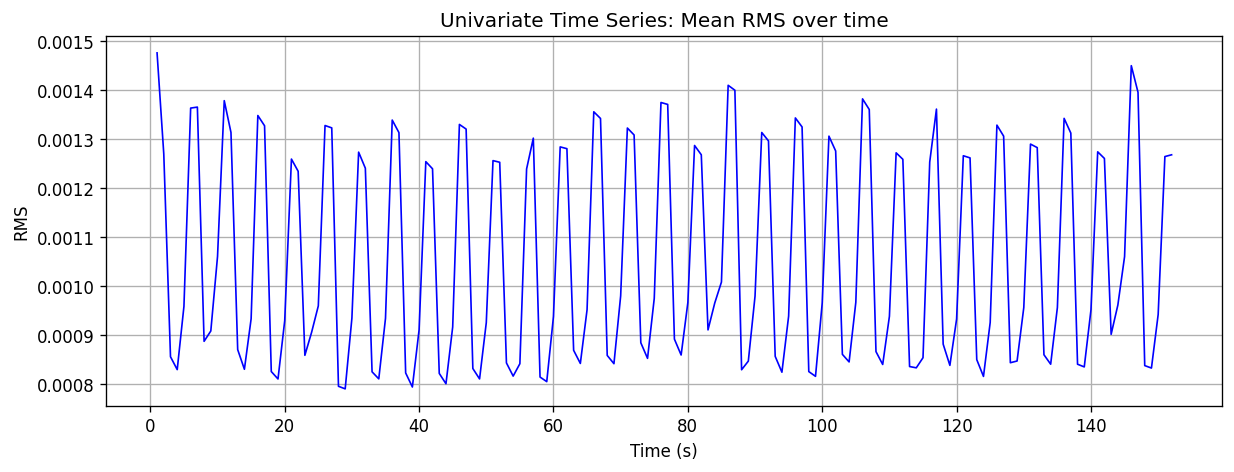

Đã lưu chuỗi thời gian thành công vào: ds003029_arima_input_timeseries.csv


In [7]:
# Cấu hình cửa sổ
WINDOW_SEC = 2.0
STEP_SEC = 1.0

w_size = int(WINDOW_SEC * sfreq)
step_size = int(STEP_SEC * sfreq)
starts = list(range(0, data.shape[1] - w_size + 1, step_size))

rows = []

for s0 in starts:
    s1 = s0 + w_size
    win = data[:, s0:s1]  # Lấy tín hiệu của tất cả các kênh trong cửa sổ
    t_mid = float(times[s0:s1].mean()) # Lấy thời gian mốc (giữa cửa sổ)
    
    # Tính RMS cho từng kênh, sau đó lấy trung bình (nanmean để bỏ qua giá trị lỗi nếu có)
    rms_per_channel = np.sqrt(np.nanmean(win ** 2, axis=1))
    rms_mean = float(np.nanmean(rms_per_channel))
    
    rows.append({
        't_mid_s': t_mid, 
        'rms': rms_mean
    })

# Tạo DataFrame chuỗi thời gian
df_timeseries = pd.DataFrame(rows)

# Trực quan hóa chuỗi thời gian vừa tạo
plt.figure(figsize=(12, 4))
plt.plot(df_timeseries['t_mid_s'], df_timeseries['rms'], color='blue', linewidth=1)
plt.title('Univariate Time Series: Mean RMS over time')
plt.xlabel('Time (s)')
plt.ylabel('RMS')
plt.grid(True)
plt.show()

# Lưu ra file CSV để dùng cho Notebook 05 (ARIMA)
output_file = "ds003029_arima_input_timeseries.csv"
df_timeseries.to_csv(output_file, index=False)
print(f"Đã lưu chuỗi thời gian thành công vào: {output_file}")